In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from datasets import load_dataset, load_from_disk

In [2]:
dataset = load_from_disk("/workdir/jz963/datasets/2024_Phytozome_Dec_Update/Phytozome_8192/")
df = dataset["test"].to_pandas()
sequences = df['seq'].tolist()
REF = df['seq'].str[4095]

In [3]:
models = ['pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536']
ctx_window = [512, 1024, 2048, 4096, 8192]

In [5]:
# Initialize list to store results
results = []

for ctx in ctx_window:
   for model in models:
       print(f"Processing {model} of context {ctx}......")
       logitPath = f'././mask_middle_token/test_{model}_{ctx}_logit.tsv'
       logits = pd.read_csv(logitPath, header=None, sep='\t')
       logits.columns = ['A', 'C', 'G', 'T']
       predictions = logits.idxmax(axis=1)
       
       # Calculate accuracy
       accuracy = (predictions == REF).mean()
       
       # Store results
       results.append({
           'model': model,
           'context': ctx,
           'accuracy': accuracy
       })

# Convert to DataFrame
results_df = pd.DataFrame(results)

Processing pcv2-l24-d0768 of context 512......
Processing pcv2-l48-d1024 of context 512......
Processing pcv2-l48-d1536 of context 512......
Processing pcv2-l24-d0768 of context 1024......
Processing pcv2-l48-d1024 of context 1024......
Processing pcv2-l48-d1536 of context 1024......
Processing pcv2-l24-d0768 of context 2048......
Processing pcv2-l48-d1024 of context 2048......
Processing pcv2-l48-d1536 of context 2048......
Processing pcv2-l24-d0768 of context 4096......
Processing pcv2-l48-d1024 of context 4096......
Processing pcv2-l48-d1536 of context 4096......
Processing pcv2-l24-d0768 of context 8192......
Processing pcv2-l48-d1024 of context 8192......
Processing pcv2-l48-d1536 of context 8192......


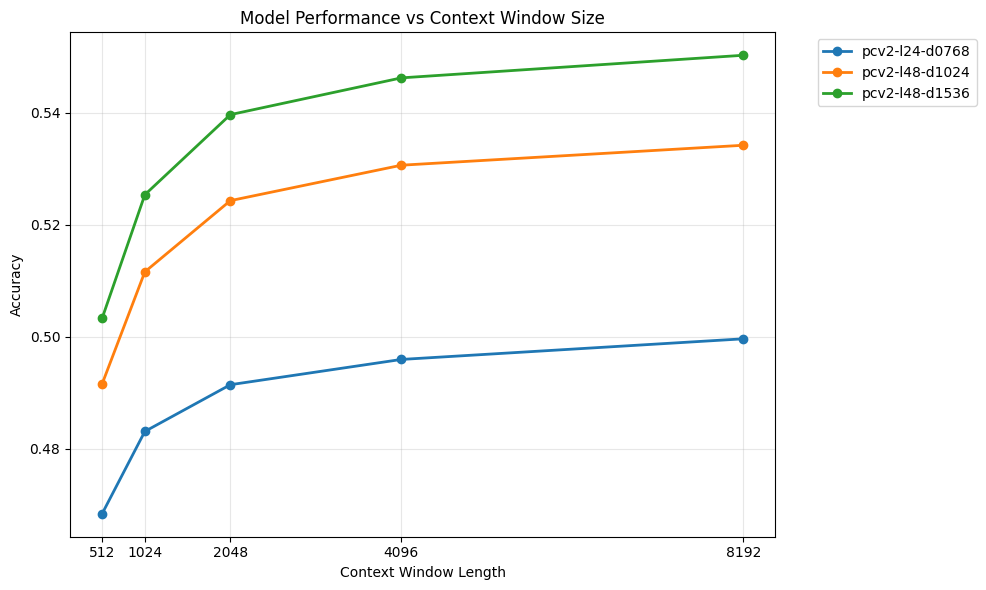

In [6]:
plt.figure(figsize=(10, 6))
models = ['pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536']

for model in models:
  model_data = results_df[results_df['model'] == model]
  plt.plot(model_data['context'], model_data['accuracy'], 
          marker='o', linewidth=2, markersize=6, label=model)

plt.xlabel('Context Window Length')
plt.ylabel('Accuracy')
plt.title('Model Performance vs Context Window Size')

plt.xticks(results_df['context'].unique())

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_vs_context_window.pdf', format='pdf', bbox_inches='tight')
plt.show()